# Deep RL Learning Dynamics in the Prisoner's Dilemma

## Motivation

In (Goll, Heitzig & Barfuss, 2024) we showed that two tabular Q-learning agents playing the Prisoner's Dilemma exhibit complex learning dynamics — transient cooperation, metastable oscillations, and sensitive dependence on the discount factor $\gamma$ — all predicted by a deterministic mean-field model. A natural follow-up question is:

> **Do these dynamics persist when we replace the tabular Q-table with a neural network (DQN)?**

If the answer is yes, it tells us that the complex dynamics are a property of the *update rule* (incremental, bootstrapping TD-learning), not the tabular representation. We then ask a second question:

> **Does the experience replay buffer — a standard component of DQN — dampen or eliminate these dynamics?**

Standard DQN (Mnih et al., 2015) samples a batch of past experiences from a replay buffer, which decorrelates the training data from the current policy. In the multi-agent setting, this breaks the tight feedback loop where both agents simultaneously adapt to each other's most recent behaviour.

Finally, we test a third hypothesis:

> **Does PPO — a policy gradient method without bootstrapping — exhibit the complex dynamics?**

PPO (Schulman et al., 2017) uses an actor-critic architecture with a clipped surrogate objective. Crucially, it does *not* use the self-referential bootstrapping term $\gamma \max_a Q(a)$ that drives oscillations in Q-learning. Instead, advantages are computed from sampled returns and a learned value baseline. If the complex dynamics are driven by the bootstrapping feedback loop, PPO should not exhibit them.

## Experimental Design

We compare five conditions, all in the two-player Prisoner's Dilemma with Boltzmann action selection:

| Condition | Algorithm | Key Parameters | Expected Dynamics |
|---|---|---|---|
| Tabular Q-learning | Q-table update | — | Complex (baseline) |
| DQN (no replay) | Neural net, gradient descent | buffer=1, batch=1 | Similar to tabular |
| DQN (buf=100) | Neural net, gradient descent | buffer=100, batch=32 | Partially damped |
| DQN (buf=10k) | Neural net, gradient descent | buffer=10k, batch=32 | Strongly damped |
| PPO | Actor-critic, clipped surrogate | $\varepsilon_{\text{clip}}$=0.2 | No complex dynamics |

The DQN uses a small MLP (1 → 32 → 2) mapping a dummy constant input to two Q-values. With `buffer_size=1` and `batch_size=1`, the DQN update reduces to training on the current experience only — analogous to the tabular update but via gradient descent on the MSE loss.

The PPO agent uses an actor-critic network with a shared hidden layer (1 → 32 → ReLU), an actor head (→ 2 policy logits) and a critic head (→ 1 value estimate $V$). It updates every step via a single-pass clipped surrogate objective with clipping parameter $\varepsilon_{\text{clip}} = 0.2$. The discount factor $\gamma$ enters only through the advantage computation $A_t = r_t + \gamma V - V$, not through a bootstrapped Q-value target.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import torch

# Import from local agent_game_sim.py (includes DQNAgent and PPOAgent)
from agent_game_sim import (
    Game, 
    Simulation, 
    QLearningAgent,
    DQNAgent,
    PPOAgent,
    reward_matrix_for_two_player_PD,
    generate_q_values
)

print("Setup complete!")
print(f"PyTorch version: {torch.__version__}")

Setup complete!
PyTorch version: 2.11.0


## Experiment Parameters

In [2]:
# ============================================================
# User-configurable parameters (change these as needed)
# ============================================================

SEED = 3
LEARNING_RATE = 0.01
TEMPERATURE = 1.0
BASE_VALUE = 0
INITIAL_PROBS = (0.5, 0.48)

# Number of time steps
NUM_STEPS_SHORT = 3000       # For gamma=0 (converges quickly)
NUM_STEPS_LONG = int(1e5)    # For gamma=0.8 (slower dynamics)

# Steady-state averaging starts from this time step
AVG_FROM_SHORT = 1000
AVG_FROM_LONG = 50000

# Experiment configurations
EXPERIMENT_CONFIGS = [
    {'type': 'tabular',                                    'label': 'Tabular Q-learning'},
    {'type': 'dqn', 'buffer_size': 1,     'batch_size': 1,  'label': 'DQN (no replay)'},
    {'type': 'dqn', 'buffer_size': 100,   'batch_size': 32, 'label': r'DQN ($B=100$)'},
    {'type': 'dqn', 'buffer_size': 10000, 'batch_size': 32, 'label': r'DQN ($B=10\,000$)'},
    {'type': 'ppo', 'update_interval': 1, 'ppo_epochs': 1,  'label': 'PPO'},
]

# ============================================================
# Structural constants (fixed by experiment design)
# ============================================================
num_players = 2
action_space = np.array([0, 1])  # 0 = cooperate, 1 = defect
observation_length = 0  # Stateless

print(f"Seed: {SEED}")
print(f"Initial probabilities: {INITIAL_PROBS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Temperature: {TEMPERATURE}")

Seed: 3
Initial probabilities: (0.5, 0.48)
Learning rate: 0.01
Temperature: 1.0


## Helper Functions

In [3]:
def run_dqn_experiment(discount_factor, initial_probs, num_time_steps,
                       buffer_size=1, batch_size=1, seed=42):
    """
    Run a DQN experiment with two agents playing Prisoner's Dilemma.
    
    Args:
        buffer_size: Replay buffer size (1 = no replay, train on current experience only)
        batch_size: Experiences sampled per training step (1 = single experience)
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    agents = [
        DQNAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            reward_func=reward_matrix_for_two_player_PD,
            learning_rate=LEARNING_RATE,
            discount_factor=discount_factor,
            temperature=TEMPERATURE,
            initial_prob=initial_probs[i],
            base_value=BASE_VALUE,
            use_prefactor=False,
            buffer_size=buffer_size,
            batch_size=batch_size
        )
        for i in range(num_players)
    ]
    
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    prob_histories = []
    for agent in agents:
        
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents,
    }


def run_ppo_experiment(discount_factor, initial_probs, num_time_steps,
                       update_interval=64, ppo_epochs=4, seed=42):
    """
    Run a PPO experiment with two agents playing Prisoner's Dilemma.
    
    Args:
        update_interval: Steps between PPO updates (1 = update every step)
        ppo_epochs: Optimization passes per update (1 = single pass)
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    agents = [
        PPOAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            reward_func=reward_matrix_for_two_player_PD,
            learning_rate=LEARNING_RATE,
            discount_factor=discount_factor,
            temperature=TEMPERATURE,
            initial_prob=initial_probs[i],
            base_value=BASE_VALUE,
            use_prefactor=False,
            update_interval=update_interval,
            ppo_epochs=ppo_epochs,
        )
        for i in range(num_players)
    ]
    
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    prob_histories = []
    for agent in agents:
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents,
    }


def run_tabular_experiment(discount_factor, initial_probs, num_time_steps, seed=42):
    """
    Run a tabular Q-learning experiment for comparison.
    """
    np.random.seed(seed)
    
    initial_q_tables = [
        np.expand_dims(generate_q_values(prob, TEMPERATURE, BASE_VALUE), axis=0)
        for prob in initial_probs
    ]
    
    agents = [
        QLearningAgent(
            player_id=i,
            action_space=action_space,
            num_players=num_players,
            discount_factor=discount_factor,
            observation_length=observation_length,
            selection_method="Boltzmann",
            reward_func=reward_matrix_for_two_player_PD,
            temperature=TEMPERATURE,
            learning_rate=LEARNING_RATE,
            q_table=initial_q_tables[i],
            use_prefactor=False
        )
        for i in range(num_players)
    ]
    
    game = Game(agents=agents)
    simulation = Simulation()
    simulation.run(game, agents, num_time_steps)
    
    prob_histories = []
    for agent in agents:
        probs = np.array([
            agent.get_action_probabilities(q_table)[0, 0]
            for q_table in agent.q_table_history
        ])
        prob_histories.append(probs)
    
    return {
        'prob_agent_0': prob_histories[0],
        'prob_agent_1': prob_histories[1],
        'agents': agents
    }


def plot_comparison(results_dict, suptitle=None, save_path=None, avg_from=None):
    """
    Plot cooperation probabilities for multiple experiments.
    Each subplot shows one experiment with both agents (blue/orange).
    
    Args:
        results_dict: dict of {label: results} pairs
        suptitle: Overall figure title
        save_path: Path to save figure
        avg_from: Time step from which to compute and display the steady-state
                    average (e.g. 50000). If None, no average lines are shown.
    """
    n = len(results_dict)
    fig, axes = plt.subplots(n, 1, figsize=(10, 2 * n), sharex=True)
    if n == 1:
        axes = [axes]
    
    for ax, (label, results) in zip(axes, results_dict.items()):
        t_max = len(results['prob_agent_0'])
        
        # Plot time series (without legend labels — added via proxies below)
        ax.plot(results['prob_agent_0'], 
                color='C0', alpha=0.9, linewidth=1.5)
        ax.plot(results['prob_agent_1'], 
                color='C1', alpha=0.9, linewidth=1.5)
        
        if avg_from is not None and avg_from < t_max:
            avg_0 = np.mean(results["prob_agent_0"][avg_from:])
            avg_1 = np.mean(results["prob_agent_1"][avg_from:])
            std_0 = np.std(results["prob_agent_0"][avg_from:])
            std_1 = np.std(results["prob_agent_1"][avg_from:])
            
            # Draw dashed average lines (without legend labels)
            ax.plot([avg_from, t_max], [avg_0, avg_0],
                    color="C0", linestyle="--", linewidth=1.5, alpha=0.8)
            ax.plot([avg_from, t_max], [avg_1, avg_1],
                    color="C1", linestyle="--", linewidth=1.5, alpha=0.8)
            
            avg_label_0 = f'$\\bar{{\\pi}}_C$ ($t > {avg_from/1e3:.0f}$k) $= {avg_0:.2f} \\pm {std_0:.2f}$'
            avg_label_1 = f'$\\bar{{\\pi}}_C$ ($t > {avg_from/1e3:.0f}$k) $= {avg_1:.2f} \\pm {std_1:.2f}$'
            
            # Column-major order for ncol=2 so each ROW is one agent:
            #   Col 1 (data)       Col 2 (mean)
            #   Agent 1 (solid)    avg_0 (dashed)
            #   Agent 2 (solid)    avg_1 (dashed)
            handles = [
                plt.Line2D([], [], color='C0', linewidth=1.5),
                plt.Line2D([], [], color='C1', linewidth=1.5),
                plt.Line2D([], [], color='C0', linewidth=1.5, linestyle='--'),
                plt.Line2D([], [], color='C1', linewidth=1.5, linestyle='--'),
            ]
            labels = ['Agent 1', 'Agent 2', avg_label_0, avg_label_1]
            ax.legend(handles, labels, loc='upper right', fontsize=10,
                      framealpha=0.9, ncol=2)
        else:
            ax.legend(['Agent 1', 'Agent 2'], loc='upper right',
                      fontsize=10, framealpha=0.9)
        
        ax.set_ylabel(f'$\\pi_C$', fontsize=11)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(label, fontsize=11)
        ax.grid(True, alpha=0.3)
    
    def formatter(x, pos):
        return f'{x/1e3:.1f}'
    axes[-1].xaxis.set_major_formatter(FuncFormatter(formatter))
    axes[-1].set_xlabel('Time step $t$ [$\\times 10^3$]', fontsize=11)
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()


print("Helper functions defined.")

Helper functions defined.


## Experiment 1: γ = 0 (Sanity Check)

With $\gamma = 0$ the bootstrapping term $\gamma \max_a Q(a)$ vanishes and the Q-learning update reduces to a simple reward-averaging rule. There is no self-referential feedback. 

For PPO, the advantage reduces to $A_t = r_t - V$ (no discounted future), so the agent simply learns from immediate rewards. It should converge to defection, serving as a sanity check.

In [4]:
print(f"Running all γ=0 experiments (t={NUM_STEPS_SHORT})...\n")

all_results_g0 = {}
for config in EXPERIMENT_CONFIGS:
    print(f"Running {config['label']}...")
    if config['type'] == 'tabular':
        result = run_tabular_experiment(
            discount_factor=0.0, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_SHORT, seed=SEED
        )
    elif config['type'] == 'ppo':
        result = run_ppo_experiment(
            discount_factor=0.0, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_SHORT,
            update_interval=config.get('update_interval', 64),
            ppo_epochs=config.get('ppo_epochs', 4), seed=SEED
        )
    else:
        result = run_dqn_experiment(
            discount_factor=0.0, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_SHORT,
            buffer_size=config['buffer_size'],
            batch_size=config['batch_size'], seed=SEED
        )
    all_results_g0[config['label']] = result

print("\nDone.")

Running all γ=0 experiments (t=3000)...

Running Tabular Q-learning...
Running DQN (no replay)...
Running DQN ($B=100$)...
Running DQN ($B=10\,000$)...
Running PPO...

Done.


Saved to PaperFigures/comparison_gamma_0.png


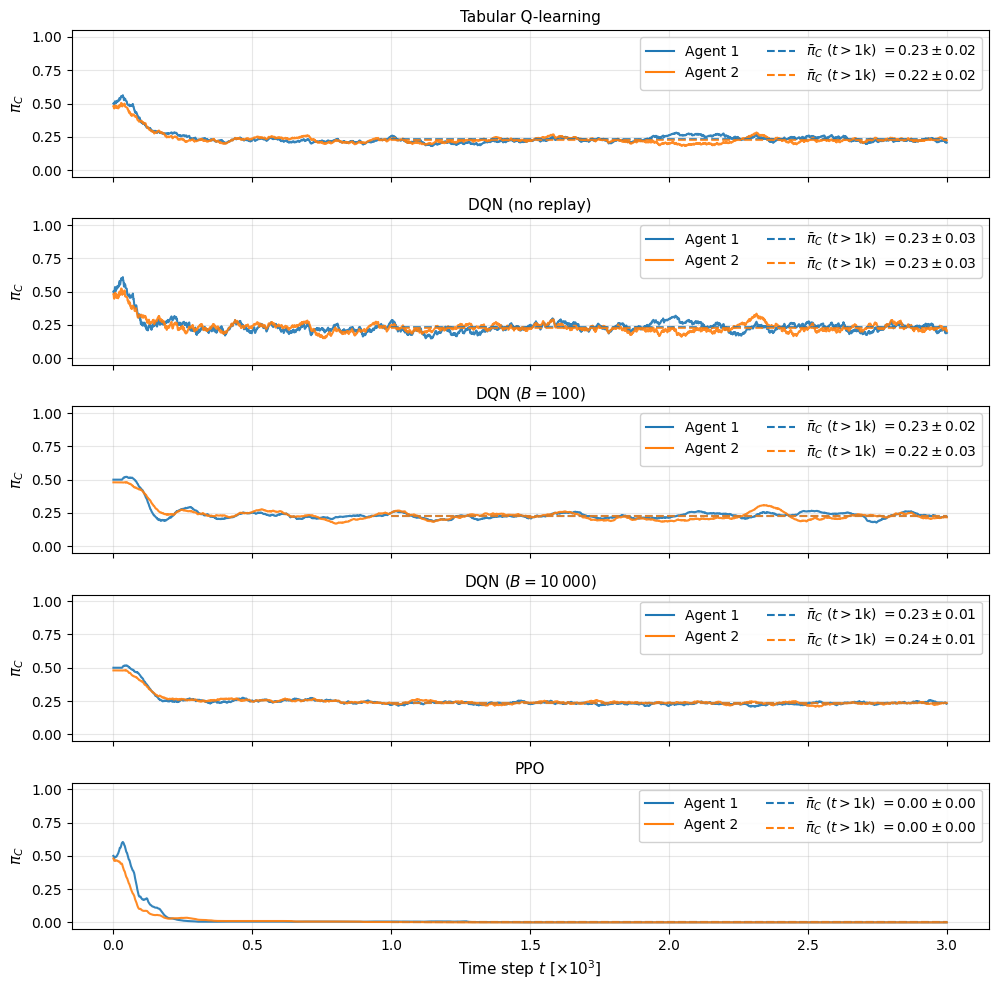

In [5]:
plot_comparison(
    all_results_g0,
    suptitle="",
    save_path='PaperFigures/comparison_gamma_0.png',
    avg_from=AVG_FROM_SHORT
)

## Experiment 2: γ = 0.8 (Complex Dynamics: Q-learning vs PPO)

With $\gamma = 0.8$, tabular Q-learning exhibits complex dynamics driven by the bootstrapping term $\gamma \max_a Q(a)$ in the TD target. Both agents simultaneously chase moving targets that depend on each other's Q-values, creating a coupled, self-referential feedback loop.

We test the hypothesis that **PPO does not exhibit these complex dynamics**. PPO updates the policy via a clipped surrogate objective using advantages $A_t = r_t + \gamma V - V$. While $\gamma$ still enters the advantage computation, the update does not involve the self-referential $\gamma \max_a Q(a)$ bootstrapping term. The critic learns a value estimate $V$ that is used as a baseline, but the policy gradient itself does not feed Q-values back into their own targets.

In [ ]:
print(f"Running all γ=0.8 experiments (t={NUM_STEPS_LONG})...\n")

all_results_g8 = {}
for config in EXPERIMENT_CONFIGS:
    print(f"Running {config['label']}...")
    if config['type'] == 'tabular':
        result = run_tabular_experiment(
            discount_factor=0.8, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_LONG, seed=SEED
        )
    elif config['type'] == 'ppo':
        result = run_ppo_experiment(
            discount_factor=0.8, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_LONG,
            update_interval=config.get('update_interval', 64),
            ppo_epochs=config.get('ppo_epochs', 4), seed=SEED
        )
    else:
        result = run_dqn_experiment(
            discount_factor=0.8, initial_probs=INITIAL_PROBS,
            num_time_steps=NUM_STEPS_LONG,
            buffer_size=config['buffer_size'],
            batch_size=config['batch_size'], seed=SEED
        )
    all_results_g8[config['label']] = result

print("\nDone.")

Running all γ=0.8 experiments (t=100000)...

Running Tabular Q-learning...
Running DQN (no replay)...
Running DQN ($B=100$)...


In [ ]:
plot_comparison(
    all_results_g8,
    suptitle="",
    save_path='PaperFigures/Fig8.jpg',
    avg_from=AVG_FROM_LONG
)

In [ ]:
# Statistics table
print(f"Average Cooperation Probabilities (γ=0.8, t > {AVG_FROM_LONG//1000}k)")
print("=" * 70)
print(f"{'Method':<35} {'Agent 1':<16} {'Agent 2':<16}")
print("-" * 70)

for name, results in all_results_g8.items():
    avg_0 = np.mean(results['prob_agent_0'][AVG_FROM_LONG:])
    avg_1 = np.mean(results['prob_agent_1'][AVG_FROM_LONG:])
    std_0 = np.std(results['prob_agent_0'][AVG_FROM_LONG:])
    std_1 = np.std(results['prob_agent_1'][AVG_FROM_LONG:])
    print(f"{name:<35} {avg_0:.3f} ± {std_0:.3f}    {avg_1:.3f} ± {std_1:.3f}")

print("-" * 70)

Average Cooperation Probabilities (γ=0.8, t > 50k)
Method                              Agent 1          Agent 2         
----------------------------------------------------------------------
Tabular Q-learning                  0.150 ± 0.129    0.162 ± 0.128
DQN (no replay)                     0.151 ± 0.131    0.158 ± 0.128
DQN ($B=100$)                       0.231 ± 0.056    0.231 ± 0.055
DQN ($B=10\,000$)                   0.228 ± 0.023    0.229 ± 0.023
PPO                                 0.000 ± 0.000    0.000 ± 0.000
----------------------------------------------------------------------


### Analysis

**PPO does not exhibit the complex dynamics.**
The PPO agents converge rapidly and monotonically to mutual defection ($\pi_C \approx 0$) at $\gamma = 0.8$, with no oscillations, transient cooperation, or metastability. This is in stark contrast to tabular Q-learning, which shows prolonged oscillatory phases with cooperation probability spiking to 0.3–0.4.

**Mechanism.** The complex dynamics in Q-learning are driven by the self-referential bootstrapping target $r + \gamma \max_a Q(a)$: each agent's Q-values feed back into their own update targets, creating a coupled feedback loop between the two agents. PPO avoids this entirely. Its policy is updated via the clipped surrogate objective $L^{\text{CLIP}} = \min(\rho_t A_t,\, \text{clip}(\rho_t, 1 \pm \varepsilon) A_t)$, where advantages $A_t = r_t + \gamma V - V$ use a learned value baseline rather than bootstrapped Q-values. The policy gradient points in the direction of higher-advantage actions without the self-referential feedback that drives oscillations in Q-learning.

This confirms that the complex dynamics are a specific consequence of the *incremental bootstrapping update rule* in Q-learning, not a general property of multi-agent reinforcement learning.

In [ ]:
if False:  # Set to True to save results
    import os
    os.makedirs('data/DQN', exist_ok=True)

    for gamma, all_results in [(0.0, all_results_g0), (0.8, all_results_g8)]:
        for label, results in all_results.items():
            probs = np.array([results['prob_agent_0'], results['prob_agent_1']])
            safe_label = label.replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
            filename = f"data/DQN/probabilities_{safe_label}_gamma_{gamma}.npy"
            np.save(filename, probs)
            print(f"Saved: {filename}")

    print("\nDone!")

## Summary

The complex learning dynamics observed in tabular multi-agent Q-learning — transient cooperation, metastable oscillations, and sensitive dependence on $\gamma$ — are a specific consequence of the *incremental bootstrapping update* $Q(a) \leftarrow Q(a) + \alpha [r + \gamma \max Q - Q(a)]$.

Three lines of evidence support this conclusion:

1. **DQN without replay reproduces the dynamics identically**, confirming they are not an artifact of the tabular representation.
2. **The DQN replay buffer dampens the dynamics** by decorrelating updates from the current joint policy.
3. **PPO does not exhibit the dynamics at all.** As a policy gradient method, PPO updates the policy via a clipped surrogate objective with advantages $A_t = r_t + \gamma V - V$. It does not use the self-referential bootstrapping term $\gamma \max_a Q(a)$, and converges monotonically to mutual defection regardless of $\gamma$.

The bootstrapping feedback loop — where each agent's Q-values feed back into their own update targets while simultaneously depending on the other agent's changing policy — is the essential driver of the complex dynamics.